# Preprocessing Teks

Notebook Tugas 2 mengolah hasil crawling Tugas 1 — 200 artikel detik.com dari
`data/crawling_detik.csv` — menjadi korpus bersih dan representasi TF-IDF yang
siap dipakai pemodelan. Data dikumpulkan dengan etika penarikan: menghormati
robots.txt, jeda minimal satu detik antar permintaan, dan User-Agent yang
wajar; notebook ini tidak melakukan permintaan jaringan baru. Alurnya: membaca
data, eksplorasi awal, kualitas teks, deteksi bahasa asing, pelestarian nama
diri, standarisasi kata tidak baku, ekstraksi kata unik, representasi TF-IDF,
dan reduksi dimensi dengan PCA.

## Membaca data

Data dibaca langsung dari berkas CSV hasil crawl. Struktur baris dan kolom
sudah dipastikan di `CRISP-DM/EDA.ipynb`; pemeriksaan di sini singkat dan
menjadi titik berangkat karena fokus notebook ini ada di tingkat isi teks.

### Struktur berkas

Ukuran dan bentuk dataset diperiksa lebih dulu: berapa baris dan kolom yang tersedia.

In [1]:
import pandas as pd

df = pd.read_csv("data/crawling_detik.csv")
df.shape

(200, 4)

Lima baris pertama memperlihatkan bentuk tiap kolom: `id`,
`isi_berita`, `label`, dan `url`.

In [2]:
df.head()

,id,isi_berita,label,url
0,1,Misi Indonesia untuk meloloskan tim 3x3 ke Oli...,sport,https://sport.detik.com/basket/d-8608204/perba...
1,2,Inilah daftar pelatih NBA terbaik sepanjang ma...,sport,https://sport.detik.com/basket/d-8296454/10-pe...
2,3,"Pelita Jaya mendapat dukungan ""tenaga"" baru un...",sport,https://sport.detik.com/basket/d-8353921/agar-...
3,4,Center Miami Heat Bam Adebayo mencetak 83 poin...,sport,https://sport.detik.com/basket/d-8395308/heat-...
4,5,Campus League 2026 Basketball Jakarta sudah me...,sport,https://sport.detik.com/basket/d-8512605/campu...


### Pemeriksaan kelengkapan

Kelengkapan baris dicek sekaligus: jumlah baris, nilai kosong, baris ganda, dan keseimbangan label.

In [3]:
checks = pd.DataFrame({
    "pemeriksaan": ["jumlah baris", "nilai kosong", "baris ganda", "URL ganda",
                    "urutan id", "jumlah per label"],
    "hasil": [len(df), df.isna().sum().sum(), df.duplicated().sum(),
              df["url"].duplicated().sum(),
              "lengkap 1-200" if list(df["id"]) == list(range(1, len(df) + 1))
              else "tidak urut",
              "; ".join(f"{k}: {v}" for k, v in df["label"].value_counts().items())],
})
checks

,pemeriksaan,hasil
0,jumlah baris,200
1,nilai kosong,0
2,baris ganda,0
3,URL ganda,0
4,urutan id,lengkap 1-200
5,jumlah per label,sport: 100; finance: 100


Semua pemeriksaan lolos: 200 baris tanpa nilai kosong maupun baris ganda, label seimbang 100:100.

## Eksplorasi awal

Sebelum pembersihan apa pun, panjang teks diamati per label agar anomali muncul
lebih dulu (artikel nyaris kosong, label timpang, panjang ekstrem).

### Panjang dan sebaran dokumen

Panjang teks per label diamati sebelum pembersihan supaya anomali (dokumen nyaris kosong, label timpang, ekor panjang) terlihat lebih dulu.

In [4]:
stats = (df.assign(panjang_karakter=df["isi_berita"].str.len(),
                       jumlah_kata=df["isi_berita"].str.split().str.len())
          .groupby("label")[["panjang_karakter", "jumlah_kata"]]
          .agg(["min", "median", "max"]))
stats

panjang_karakter                jumlah_kata             
                     min  median    max         min median   max
label                                                           
finance             1210  2501.0  14106         161  315.5  1930
sport                924  2409.0   5809         144  339.0   801

Panjang dokumen sehat: dokumen terpendek (sport) tetap berisi
beberapa kalimat utuh dan label seimbang. Ekor panjang di finance berasal dari
berita yang memuat tabel angka; tabel seperti ini akan disisihkan pada tahap
artefak format. Sebarannya dilihat sekilas agar anomali ekor terlihat.

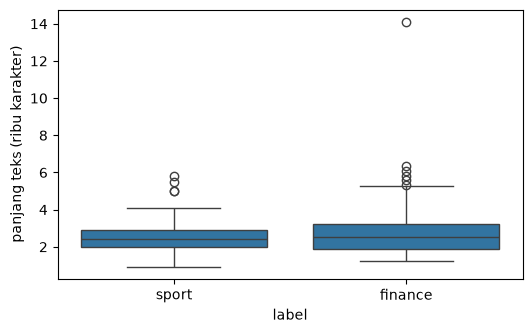

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(6, 3.5))
sns.boxplot(data=df, x="label", y=df["isi_berita"].str.len() / 1000, ax=ax)
ax.set_ylabel("panjang teks (ribu karakter)")
plt.show()

## Kualitas teks: artefak format

Pengecekan pertama di tingkat teks: karakter di luar ASCII Amerika (aksen,
emoji, tanda hubung non-breaking) dilacak per artikel.

### Karakter khusus dan normalisasi

Karakter di luar ASCII Amerika — aksen, emoji, tanda hubung non-breaking — ditelusuri per artikel.

In [6]:
def chars_outside_ascii(text):
    return sorted({c for c in text if ord(c) > 127})

rows = []
for _, r in df.iterrows():
    extra = chars_outside_ascii(r["isi_berita"])
    if extra:
        rows.append({"id": r["id"], "label": r["label"],
                     "karakter": " ".join(extra)})
pd.DataFrame(rows)

,id,label,karakter
0,19,sport,— …
1,57,sport,í
2,66,sport,‑
3,89,sport,➡ ️ 📺
4,91,sport,é
5,181,finance,é


Enam artikel membawa karakter khusus. Aksen muncul pada nama
diri (Augustí, Nestlé), emoji pada satu kutipan cuitan, dan tanda hubung
non-breaking pada satu artikel. Aksen dinormalisasi ke huruf dasar (nama tetap
terbaca), tanda hubung non-breaking disamakan dengan tanda hubung biasa, dan
emoji serta simbol lain dibuang pada tahap pembersihan simbol. Contoh sebelum
dan sesudah:

In [7]:
import unicodedata

def normalize_letters(text):
    decomposed = unicodedata.normalize("NFD", text)
    text = "".join(c for c in decomposed if not unicodedata.combining(c))
    return text.replace("\u2011", "-").replace("\u2010", "-")

sample = df.set_index("id").loc[[19, 57, 66, 89, 91, 181], "isi_berita"]
pd.DataFrame({
    "id": sample.index,
    "sebelum": [t[:90] for t in sample],
    "sesudah": [normalize_letters(t)[:90] for t in sample],
})

,id,sebelum,sesudah
0,19,Bintang Memphis Grizzlies Brandon Clarke menin...,Bintang Memphis Grizzlies Brandon Clarke menin...
1,57,Kehadiran wasit asing pada fase Playoffs IBL 2...,Kehadiran wasit asing pada fase Playoffs IBL 2...
2,66,Format baru Indonesia Basketball League (IBL) ...,Format baru Indonesia Basketball League (IBL) ...
3,89,San Antonio Spurs akan menghadapi New York Kni...,San Antonio Spurs akan menghadapi New York Kni...
4,91,FIBA mempertegas komitmennya dalam mendorong p...,FIBA mempertegas komitmennya dalam mendorong p...
5,181,"Pertumbuhan sektor pariwisata, hospitality, da...","Pertumbuhan sektor pariwisata, hospitality, da..."


### Cacah dan sumber artefak

Korpus dicacah dalam dua kondisi: teks asli dan teks sesudah operasi naif (huruf kecil, angka serta simbol diganti spasi). Operasi naif inilah yang menciptakan artefak; besarnya menjadi dasar keputusan pembersihan.

In [8]:
import re
from collections import Counter

def naive_tokens(text):
    return re.sub(r"[^a-z\s]", " ", text.lower()).split()

naive = [w for doc in df["isi_berita"] for w in naive_tokens(doc)]
naive_counts = Counter(naive)
single = {w: n for w, n in naive_counts.items() if len(w) == 1}
double = {w: n for w, n in naive_counts.items() if len(w) == 2}
total_naive = len(naive)

pd.DataFrame({
    "metrik": ["token total", "kata unik", "token satu huruf", "token dua huruf"],
    "jumlah": [total_naive, len(naive_counts), sum(single.values()),
               sum(double.values())],
    "proporsi": ["100%", f"{100 * len(naive_counts) / total_naive:.2f}%",
                 f"{100 * sum(single.values()) / total_naive:.2f}%",
                 f"{100 * sum(double.values()) / total_naive:.2f}%"],
})

,metrik,jumlah,proporsi
0,token total,72138,100%
1,kata unik,7544,10.46%
2,token satu huruf,425,0.59%
3,token dua huruf,2878,3.99%


Token satu dan dua huruf menyumbang hampir 4,6% dari seluruh
token. Kedua kelas inilah sumber potongan yang tidak bermakna; masing-masing
dibedah dengan konteks aslinya.

### Sensus token satu huruf

Token satu huruf dihitung, lalu konteks aslinya diambil untuk mengetahui dari mana setiap huruf berasal.

In [9]:
pd.DataFrame([{"huruf": w, "jumlah": n}
               for w, n in sorted(single.items(), key=lambda x: -x[1])])

,huruf,jumlah
0,x,89
1,u,64
2,i,39
3,s,34
4,b,32
5,a,27
6,d,22
7,e,17
8,y,16
9,p,13


Konteks di teks asli diambil untuk huruf-huruf dengan
kemunculan terbanyak.

In [10]:
def context(texts, token, window=25):
    for text in texts:
        for m in re.finditer(r"(?<![A-Za-z])" + token + r"(?![A-Za-z])",
                             text, re.IGNORECASE):
            start = max(0, m.start() - window)
            return text[start:m.end() + window].replace("\n", " ")

pd.DataFrame([{"huruf": w,
               "konteks": context(list(df["isi_berita"]), w)}
              for w in ["x", "u", "i", "s", "b", "a", "d", "h", "m"]])

,huruf,konteks
0,x,ia untuk meloloskan tim 3x3 ke Olimpiade mulai...
1,u,menjadi tuan rumah FIBA U16 Asia Cup 2027 dan...
2,i,nt-athlete NCAA Division I bersama Grand Canyo...
3,s,tempur di FIBA 3x3 Women's Series Xiantao Stop...
4,b,"a tertinggi Liga Jepang, B.LEAGUE Premier. Seb..."
5,a,ue Asia - East 2026. Lag a Kemenangan di level...
6,d,"esia akan gabung di Pool D. Di Pool ini, Indon..."
7,h,a MR.D.I.Y. Indonesia di H1 2026 | Aktual (dal...
8,m,1 pic.twitter.com/5AxI6j8m35 Rataan poin Adeba...


Tidak ada satu pun huruf tunggal yang berdiri sendiri sebagai
kata: `x` dari `3x3`, `u` dari `U-16`/`U-18`, `i` dari `Division I` dan
`kuartal I`, `s` dari `Women's` genitif Inggris, `b`/`a`/`d` dari kode grup
(`Grup B/A/D`, `Pool D`), `h` dari `H1 2026`, `m` dari inisial nama dan potongan
URL cuitan. Semuanya pecahan komposit yang akan dipertahankan utuh atau dibuang
pada tahap proteksi. Keputusan: token satu huruf tidak pernah menjadi fitur,
panjang minimum 2.

### Sensus token dua huruf

Dengan cara yang sama, token dua huruf (2.878 kemunculan pada cacah naif) diperiksa satu per satu berikut konteksnya.

In [11]:
rows = []
for w, n in sorted(double.items(), key=lambda x: -x[1]):
    if n >= 3:
        rows.append({"token": w, "jumlah": n,
                     "konteks": context(list(df["isi_berita"]), w)})
pd.DataFrame(rows)

,token,jumlah,konteks
0,di,1436,"selama dua hari (4-5/8), di Kantor Perbasi, GB..."
1,rp,285,ut yang dikalikan dengan Rp 1.000.000 (satu ju...
2,ke,260,untuk meloloskan tim 3x3 ke Olimpiade mulai di...
3,ia,133,total 1.390 kemenangan. Ia mendapat gelar seb...
4,us,75,et kelolaan besar hingga US$ 1 triliun. Dengan...
5,ya,52,"lau one on one challenge ya bisa lah,"" ujarnya..."
6,of,46,"nt guard yang masuk Hall of Fame, Wilkens memi..."
7,vs,36,ajikan San Antonio Spurs vs New York Knicks. J...
8,ri,36,"et terbaik akan mewakili RI di Berlin, Jerman...."
9,pt,30,berada di bawah naungan PT. Ambisi Dahsyat Ge...


Token dua huruf terbagi tiga kelas. Pertama, kata fungsi
Indonesia yang berdiri sendiri (`di`, `ke`, `ia`, `ya`). Kedua, lambang,
satuan, dan singkatan (`rp` rupiah, `us` dari `US$`, `ri`, `pt`, `bi`, `ku`
singkatan "Kelompok Umur", `kg` satuan, `hr` Harga Referensi, angka Romawi
`iv`/`ii`/`xi`). Ketiga, partikel Inggris pada rentas yang dipertahankan (`of`
pada Hall of Fame, `vs` pada pertandingan, `up` pada runner-up, `on`/`to`/`in`/
`by` pada kutipan). Kelas pertama dipisahkan secara objektif memakai daftar
stopword bahasa Indonesia.

In [12]:
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

id_stopwords = set(StopWordRemoverFactory().get_stop_words())
tokens_2huruf = [w for w, n in double.items() if n >= 3]
(pd.DataFrame({"token": tokens_2huruf,
               "jumlah": [double[w] for w in tokens_2huruf],
               "stopword Indonesia": [w in id_stopwords for w in tokens_2huruf]})
    .sort_values("jumlah", ascending=False))

,token,jumlah,stopword Indonesia
2,di,1436,True
14,rp,285,False
0,ke,260,True
3,ia,133,True
35,us,75,False
10,ya,52,True
4,of,46,False
25,ri,36,False
7,vs,36,False
26,pt,30,False


Hanya `di`, `ke`, `ia`, `ya` yang terdaftar sebagai kata
fungsi; `oh` yang juga terdaftar muncul sekali sebagai seruan wajar. Kelas dua
dan tiga dibuang: satuan dan singkatan bukan term, dan partikel asing dua huruf
tidak menjadi fitur (kebijakan panjang minimum) sementara inti namanya (`hall`,
`fame`, `lakers`) tetap ada.

## Deteksi bahasa asing

Sisipan bahasa asing diperlakukan dengan prinsip pertahankan-dulu. Deteksi
dilakukan dua tingkat: kalimat dan token.

### Gambaran bahasa per kalimat

Teks dipotong menjadi kalimat dan setiap kalimat dilabeli bahasanya dengan `langid`, untuk melihat proporsi sisipan asing.

In [13]:
import langid

sentences, article_ids = [], []
for _, row in df.iterrows():
    parts = [p.strip()
             for p in re.split(r"(?<=[.!?])\s+|\n+", row["isi_berita"])
             if p.strip()]
    sentences.extend(parts)
    article_ids.extend([row["id"]] * len(parts))

lang_labels = [langid.classify(s)[0] for s in sentences]
lang_counts = Counter(lang_labels)
(pd.DataFrame({"bahasa": list(lang_counts),
               "kalimat": list(lang_counts.values()),
               "proporsi": [f"{100 * k / len(sentences):.1f}%"
                            for k in lang_counts.values()]})
    .sort_values("kalimat", ascending=False))

,bahasa,kalimat,proporsi
0,id,3868,74.0%
3,ms,569,10.9%
1,en,444,8.5%
5,es,57,1.1%
19,pt,42,0.8%
11,de,38,0.7%
10,it,26,0.5%
14,jv,23,0.4%
6,pl,22,0.4%
9,sv,18,0.3%


Bahasa Indonesia mendominasi; label Melayu dan Inggris
menyusul. Kalimat berlabel `en` yang panjangnya minimal 8 kata ditampilkan
untuk melihat mana yang benar-benar prosa Inggris dan mana yang sekadar
fragmen.

In [14]:
en_long = []
for s, lang, aid in zip(sentences, lang_labels, article_ids):
    if lang == "en" and len(s.split()) >= 8:
        en_long.append({"id": aid, "kalimat": s})
pd.DataFrame(en_long).assign(kalimat=lambda d: d["kalimat"].str[:96] + "...")

,id,kalimat
0,2,"Semasa kariernya, Brown memimpin Denver Nugget..."
1,4,| Wilt Chamberlain | 100 | 1962-03-02 | PHW |...
2,4,| Bam Adebayo | 83 | 2026-03-10 | MIA |...
3,4,| Kobe Bryant | 81 | 2006-01-22 | LAL |...
4,4,| Wilt Chamberlain | 78 | 1961-12-08 | PHW |...
5,4,| Wilt Chamberlain | 73 | 1962-11-16 | SFW |...
6,4,| Wilt Chamberlain | 73 | 1962-01-13 | PHW |...
7,4,| Wilt Chamberlain | 72 | 1962-11-03 | SFW |...
8,4,| Joel Embiid | 70 | 2024-01-22 | PHI |...
9,4,| Devin Booker | 70 | 2017-03-24 | PHO |...


Dari 33 baris, hampir semua adalah tabel, daftar nama, dan
fragmen berlabel salah karena padat nama asing. Prosa Inggris sesungguhnya
hanya empat kalimat pada dua artikel: pernyataan resmi komisioner NBA (id 19)
dan tema konferensi (id 146). Keduanya kutipan dan judul resmi yang
diterjemahkan justru berisiko mengubah makna; dipertahankan apa adanya.

### Uji deteksi per token

Deteksi per token diuji pada kata-kata Indonesia yang paling umum. Cara ini baru bisa dipakai jika kata biasa pun terlabel `id`.

In [15]:
probe = ["dan", "di", "ke", "dalam", "pada", "akan", "juga",
         "satu", "tim", "karena", "itu", "ini", "pemerintah", "sepak", "bola",
         "bank", "saham", "untuk"]
pd.DataFrame({"kata": probe,
              "hasil langid": [langid.classify(w)[0] for w in probe]})

,kata,hasil langid
0,dan,en
1,di,en
2,ke,en
3,dalam,en
4,pada,en
5,akan,en
6,juga,en
7,satu,en
8,tim,en
9,karena,en


`langid` memberi label Inggris pada kata Indonesia yang paling
umum sekalipun (`dan`, `di`, `ke`, `dalam`, `pada`, `akan`), dan label acak
untuk kata lain (`saham` → bahasa Ceko, `untuk` → Finlandia). Filter per token
hanya akan membuang kata Indonesia sendiri.

Sebagai gantinya, kata asing pada kalimat Inggris yang panjang
diperiksa: apakah benar kata serapan atau hanya nama diri.

In [16]:
token_in_en = Counter()
for s, lang in zip(sentences, lang_labels):
    if lang == "en" and len(s.split()) >= 8:
        token_in_en.update(re.findall(r"[A-Za-z]+", s.lower()))

corpus_words = Counter(
    w for t in df["isi_berita"] for w in re.findall(r"[A-Za-z]+", t.lower()))
cap_forms = Counter(
    w.lower() for t in df["isi_berita"]
    for w in re.findall(r"[A-Za-z]+", t) if w[0].isupper())

rows = []
for w, n_en in token_in_en.most_common(20):
    rows.append({"kata": w, "di kalimat en": n_en, "total korpus": corpus_words[w],
                 "muncul kapital": cap_forms[w]})
pd.DataFrame(rows)

,kata,di kalimat en,total korpus,muncul kapital
0,wilt,9,15,15
1,chamberlain,9,14,14
2,the,5,43,34
3,of,5,46,1
4,phw,4,4,4
5,sfw,4,4,4
6,brandon,3,6,6
7,ers,2,17,0
8,pistons,2,10,10
9,knicks,2,95,95


Kandidat kata asing pada kalimat Inggris hampir semuanya nama diri
(Wilt, Chamberlain, Knicks, Lakers) yang bentuk kapitalnya konsisten — kolom
"muncul kapital" menyamai "total korpus"; sisa baris hanyalah partikel Inggris
pada kutipan yang dipertahankan (`the`, `of`). Istilah
jurnalistik yang sudah mapan (`season`, `game`, `runner-up`, `fans`) dipakai
sebagai leksikon baku media Indonesia; padanan Indonesianya sering sudah
berdampingan ("juara dan runner-up"), sehingga menerjemahkannya tidak menambah
informasi. Keputusan: tidak ada token yang diterjemahkan — seluruh konten asing
dipertahankan.

## Pelestarian nama diri

Keputusan artefak di atas menuntut pembersihan yang menjaga nama diri dan
komposit bermakna. Komposit alfanumerik diblokir sebagai satu kesatuan sebelum
angka dan simbol dibuang, supaya tidak menyisakan pecahan seperti `x` (`3x3`),
`u` (`U-18`), `ers` (`76ers`), `ga` (`GA-604`), `mi` (`P2MI`).

### Proteksi komposit alfanumerik

Komposit bermakna — URL, lambang mata uang, kata berangka — diblokir sebagai satu kesatuan sebelum angka dan simbol dibuang, agar tidak tersisa pecahan seperti `x` dari `3x3`.

In [17]:
url_pattern = re.compile(r"(?:https?://|www\.|pic\.twitter\.com/)\S+")
alnum_pattern = re.compile(
    r"\b(?=[A-Za-z]*\d)[A-Za-z0-9][A-Za-z0-9.*-]*\b")
currency_pattern = re.compile(
    r"\bRp\d[\d.,]*\b|\bUS\$\d[\d.,]*\b|\b\$\d[\d.,]*\b|\bRp\b|\bUS\$\b")
roman_pattern = re.compile(
    r"\b(?:iii|iv|vi{0,3}|i[ivx]{0,2}|v|x{1,3}|xi{0,3})\b", re.IGNORECASE)

n_url = sum(len(url_pattern.findall(t)) for t in df["isi_berita"])
n_alnum = sum(len(alnum_pattern.findall(t)) for t in df["isi_berita"])
n_curr = sum(len(currency_pattern.findall(t)) for t in df["isi_berita"])
n_roman = sum(len(roman_pattern.findall(t)) for t in df["isi_berita"])

pd.DataFrame({
    "jenis": ["URL", "komposit alfanumerik dan angka", "lambang mata uang",
              "angka Romawi"],
    "kemunculan": [n_url, n_alnum, n_curr, n_roman],
    "contoh": ["pic.twitter.com/ZjxXtIycwl", "3x3, U-18, 76ers, 2026, GA-604",
               "Rp, US$", "IV, VIII, XI"],
})

,jenis,kemunculan,contoh
0,URL,5,pic.twitter.com/ZjxXtIycwl
1,komposit alfanumerik dan angka,4073,"3x3, U-18, 76ers, 2026, GA-604"
2,lambang mata uang,285,"Rp, US$"
3,angka Romawi,126,"IV, VIII, XI"


Angka Romawi lepas (`IV`, `VIII`, `XI` pada "Komisi XI",
"Wakil Rektor IV") adalah penomoran, bukan term, dan ikut disisihkan bersama
URL dan lambang mata uang. Efeknya terhadap token satu dan dua huruf diukur
dengan membandingkan cacah naif dan cacah setelah proteksi, pembersihan simbol,
serta panjang minimum 2.

In [18]:
def protect(text):
    text = url_pattern.sub(" ", text)
    text = currency_pattern.sub(" ", text)
    text = alnum_pattern.sub(" ", text)
    text = roman_pattern.sub(" ", text)
    return text.replace("\u2011", "-")

def clean_part1(text):
    text = normalize_letters(protect(text))
    text = re.sub(r"[^A-Za-z\s-]", " ", text)
    text = re.sub(r"-+", " ", text)
    return " ".join(w for w in text.split() if len(w) >= 2)

corpus_clean_1 = [clean_part1(t) for t in df["isi_berita"]]
tokens_1 = [w.lower() for doc in corpus_clean_1 for w in doc.split()]
counts_1 = Counter(tokens_1)

pd.DataFrame({
    "kondisi": ["naif (teks asli)", "setelah proteksi dan strip (min. 2 huruf)"],
    "token total": [total_naive, len(tokens_1)],
    "kata unik": [len(naive_counts), len(counts_1)],
    "token satu huruf": [sum(single.values()),
                         sum(n for w, n in counts_1.items() if len(w) == 1)],
    "token dua huruf": [sum(double.values()),
                        sum(n for w, n in counts_1.items() if len(w) == 2)],
})

,kondisi,token total,kata unik,token satu huruf,token dua huruf
0,naif (teks asli),72138,7544,425,2878
1,setelah proteksi dan strip (min. 2 huruf),71234,7500,0,2471


Token satu huruf hilang total (425 → 0). Token dua huruf turun
dari 2.878 ke 2.471 — komposit tidak lagi menyisakan `us` (`US$`), `ga`, `mi`.
Sisanya adalah kata fungsi (`di`, `ke`, `ia`, `ya`), partikel asing (`of`,
`vs`, `up`), dan singkatan lepas (`ri`, `pt`, `bi`, `ku`, `kg`, `hr`) yang
akan tersaring oleh kebijakan kata fungsi.

### Partikel dalam nama multi-kata

Partikel pendek di dalam nama asing (`of`, `la`, `de`) dilihat langsung di konteksnya, karena menjadi bagian dari rentas nama yang dipertahankan.

In [19]:
pd.DataFrame([{"pola": w,
               "konteks": context(list(df["isi_berita"]), w)}
              for w in ["of", "la", "de"]])

,pola,konteks
0,of,"nt guard yang masuk Hall of Fame, Wilkens memi..."
1,la,s melewati rekor legenda LA Lakers Kobe Bryant...
2,de,emas Olimpiade 2016 Rio de Janeiro ini sekali...


Dengan kebijakan panjang minimum, partikel dua huruf tidak
menjadi fitur sedangkan inti namanya tetap ada. Nama diri berkapital di tengah
kalimat dicacah sebagai sinyal perlindungan utama.

### Sensus nama diri

Nama diri disinyalir oleh huruf kapital di tengah kalimat; sinyal ini diukur dengan mencacah semua kemunculannya.

In [20]:
def mid_sentence(text, pos):
    i = pos - 1
    while i >= 0 and text[i] in ' \n\t"\'":(':
        i -= 1
    return i >= 0 and text[i] not in '.!?;:(\u2013\u2014'

name_counts = Counter()
for text in df["isi_berita"]:
    for m in re.finditer(r"[A-Za-z]+", text):
        w = m.group(0)
        if (len(w) >= 3 and w[0].isupper()
                and mid_sentence(text, m.start())):
            name_counts[w.lower()] += 1

pd.DataFrame({
    "metrik": ["nama diri unik", "kemunculan total",
               "nama dengan >= 3 kemunculan"],
    "jumlah": [len(name_counts), sum(name_counts.values()),
               sum(1 for n in name_counts.values() if n >= 3)],
})

,metrik,jumlah
0,nama diri unik,3091
1,kemunculan total,14332
2,nama dengan >= 3 kemunculan,1053


Kelima belas nama teratas memperlihatkan dominasi topik:
`indonesia`, `jakarta`, `jaya` (halaman olahraga), `ibl` (liga basket),
`prabowo`, `kpk`, `presiden` pada berita finance.

In [21]:
pd.DataFrame([{"nama": w, "kemunculan": n}
               for w, n in name_counts.most_common(15)])

,nama,kemunculan
0,indonesia,414
1,jakarta,274
2,jaya,175
3,ibl,159
4,pelita,150
5,nba,146
6,basketball,117
7,universitas,90
8,purbaya,90
9,spurs,84


## Standarisasi kata tidak baku

Kamus `indoNLP` (kamus-alay, 4.331 entri) diujicobakan dulu dengan pemakaian
seadanya: setiap kata yang cocok diganti, tanpa pengecualian.

### Cacah dampak kamus

Dampak pemakaian seadanya diukur: berapa kemunculan yang tersentuh kamus dan berapa di antaranya diduga nama diri.

In [22]:
from indoNLP.preprocessing import replace_slang

slang_hit = Counter()
cap_hit = Counter()
for text in df["isi_berita"]:
    for m in re.finditer(r"[A-Za-z]+", text):
        w = m.group(0)
        if replace_slang(w.lower()) != w.lower():
            slang_hit[w.lower()] += 1
            if w[0].isupper() and mid_sentence(text, m.start()):
                cap_hit[w.lower()] += 1

pd.DataFrame({
    "metrik": ["token kena kamus", "kemunculan berubah",
               "kemunculan nama diri (kapital tengah kalimat)"],
    "jumlah": [len(slang_hit), sum(slang_hit.values()), sum(cap_hit.values())],
})

,metrik,jumlah
0,token kena kamus,76
1,kemunculan berubah,563
2,kemunculan nama diri (kapital tengah kalimat),274


Kamus mentah menyentuh 563 kemunculan dan 274 di antaranya
berkapital di tengah kalimat — sinyal nama diri. Peringkat atas mengikuti jumlah
kapital tengah kalimat.

### Tabrakan kamus dengan nama diri

Peringkat atas diperiksa untuk menemukan token yang masuk kamus padahal bukan bahasa gaul.

In [23]:
rows = []
for w in sorted(slang_hit, key=lambda x: -cap_hit[x]):
    rows.append({"token": w, "kemunculan": slang_hit[w],
                 "kapital tengah": cap_hit[w],
                 "padanan kamus": replace_slang(w)})
pd.DataFrame(rows[:15])

,token,kemunculan,kapital tengah,padanan kamus
0,u,64,64,lu
1,mbg,34,32,mbak
2,sma,26,21,sama
3,gt,20,20,begitu
4,pass,13,13,pas
5,usa,11,10,usah
6,c,10,10,sih
7,m,12,9,sama
8,do,9,9,di
9,d,22,7,di


Peringkat atas berisi token yang jelas bukan bahasa gaul:
`u` (U-18 → lu), `mbg` (Makan Bergizi Gratis → mbak), `sma` (sekolah → sama),
`pass` (nama produk → pas), `gt` (gerbang tol → begitu), `hr` (Harga Referensi
→ hari), `usa` (nama tim → usah), `m` (inisial nama → sama). Sebelum
dikecualikan, konteks kata yang mencurigakan diperiksa.

### Pemeriksaan konteks

Kata yang paling mencurigakan dicek langsung di konteks teks asli sebelum diputuskan dikecualikan.

In [24]:
pd.DataFrame([{"kata": w,
               "konteks": context(list(df["isi_berita"]), w)}
              for w in ["dunk", "slam", "minta", "fans", "pala", "masukin"]])

,kata,konteks
0,dunk,) - 29 poin (final) Slam Dunk Contest - Keshad...
1,slam,azers) - 29 poin (final) Slam Dunk Contest - K...
2,minta,"nton juga video ""Prabowo Minta Mendiktisaintek..."
3,fans,Kapten tim dipilih oleh fans dalam sistem vot...
4,pala,", meliputi kelapa, lada, pala, tebu, kopi, kak..."
5,masukin,"Danantara tuh, kita akan masukin ke PNBP situ...."


Konteksnya membenarkan pengecualian: `dunk` dan `slam`
istilah olahraga yang mapan di media Indonesia, `fans` kata asing yang dipakai
apa adanya, `pala` rempah (bukan gaul), `masukin` padanan bakunya "memasukkan"
sementara kamus memberi "memasuki", dan `minta` kata baku (kemunculannya
bercampur dengan bentuk `meminta` yang sudah baku) sehingga salah dikira gaul.
Penerapan kamus kemudian disaring dengan empat aturan: (1) kata berkapital
penuh, berhuruf campuran, atau berkapital di tengah kalimat dianggap nama;
(2) kata yang berdampingan angka dianggap satuan; (3) pola `(aaa/bbb)` kode
jurnalis di akhir artikel dikecualikan; (4) token dua huruf selain kata fungsi
dikecualikan. Perubahan yang lolos saringan:

### Saringan akhir

Kamus diterapkan setelah empat aturan pengecualian. Kata yang benar-benar diubah:

In [25]:
excluded_slang = {"dunk", "slam", "minta", "fans", "pala", "masukin"}
slang_changes = Counter()

def guarded_replace(text):
    changes = []
    for m in re.finditer(r"[A-Za-z]+", text):
        w = m.group(0)
        repl = replace_slang(w.lower())
        if repl == w.lower() or w.lower() in excluded_slang:
            continue
        before = text[max(0, m.start() - 6):m.start()]
        after = text[m.end():m.end() + 6]
        near_digit = bool(re.search(r"\d", before + after))
        byline = bool(re.search(r"\(\w{2,6}/\w{2,6}\)",
                                text[m.start() - 6:m.end() + 6]))
        looks_name = (w.isupper() or any(c.isupper() for c in w[1:])
                      or (w[:1].isupper() and w[1:].islower()
                          and mid_sentence(text, m.start())))
        two_letter = len(w) <= 2 and w.lower() not in id_stopwords
        if not (near_digit or byline or looks_name or two_letter):
            changes.append((m.start(), m.end(), repl))
            slang_changes[w.lower()] += 1
    out = list(text)
    for s, e, r in reversed(changes):
        out[s:e] = list(r)
    return "".join(out)

def clean_full(text):
    text = normalize_letters(protect(text))
    text = guarded_replace(text)
    text = re.sub(r"[^A-Za-z\s-]", " ", text)
    text = re.sub(r"-+", " ", text)
    words = [w for w in text.split() if len(w) >= 2]
    return " ".join(w for w in words
                    if not (len(w) == 2 and w.lower() not in id_stopwords))

final_docs = [clean_full(t).split() for t in df["isi_berita"]]
post_counts = Counter(w.lower() for doc in final_docs for w in doc)

applied_rows = []
for w, cnt in sorted(slang_changes.items()):
    applied_rows.append({"kata": w, "diubah": cnt,
                         "padanan": replace_slang(w),
                         "di korpus akhir": post_counts.get(replace_slang(w), 0)})
pd.DataFrame(applied_rows)

,kata,diubah,padanan,di korpus akhir
0,aja,7,saja,66
1,dah,1,deh,2
2,dapet,2,dapat,177
3,gimana,1,bagaimana,45
4,gini,1,begini,1
5,gitu,9,begitu,32
6,narik,1,menarik,22
7,ngerti,1,mengerti,1
8,nggak,36,enggak,43
9,ngomong,1,mengomong,1


Saringan menyisakan 17 kata gaul (72 kemunculan) yang
semuanya berpadanan baku jelas. `nggak` → `enggak` paling banyak; sisanya satu
sampai sembilan kali. Kolom "diubah" adalah jumlah kemunculan yang diganti
selama pembersihan; "di korpus akhir" adalah jumlah padanan bakunya di korpus
akhir (termasuk yang memang sudah baku sejak awal).

### Token yang ditahan

Token yang ditahan saringan diperiksa sekali lagi agar dipastikan tidak ada nama diri yang rusak.

In [26]:
blocked_rows = []
for w in sorted(post_counts):
    if replace_slang(w) != w:
        blocked_rows.append({"kata": w, "kemunculan": post_counts[w],
                             "padanan kamus": replace_slang(w)})
pd.DataFrame(blocked_rows)

,kata,kemunculan,padanan kamus
0,akn,4,akan
1,bca,1,baca
2,bird,3,biru
3,cba,1,coba
4,dede,1,adek
5,dhe,1,deh
6,dunk,10,dong
7,fans,4,fan
8,masukin,1,memasuki
9,may,1,mau


Token yang ditahan tetap utuh: `dunk` dan `slam` istilah
olahraga, `minta` kata baku, `mbg`/`smp`/`sma` akronim, `pass` nama produk,
`usa` kebangsaan, serta nama diri (`bird`, `dede`, `cba`, `bca`, `dhe`, `may`,
`pan`). `akn` berasal dari kode jurnalis di akhir artikel, `tot` adalah bentuk
asli `ToT` yang terlindungi aturan huruf campuran, dan `ngarang` dari judul
acara. Tidak ada nama atau akronim yang rusak.

### Korpus akhir

Korpus bersih dirangkum: total token, kosakata per label, dan sisa token dua huruf.

In [27]:
all_final = [w.lower() for doc in final_docs for w in doc]
final_counts = Counter(all_final)
label_counts = Counter()
for doc, label in zip(final_docs, df["label"]):
    label_counts[label] += len(doc)
two_letter_final = {w: n for w, n in final_counts.items() if len(w) == 2}

pd.DataFrame({
    "metrik": ["token total", "kata unik", "token dua huruf tersisa",
               "token per label"],
    "jumlah": [sum(final_counts.values()), len(final_counts),
               ", ".join(f"{w}: {final_counts[w]}"
                         for w in sorted(two_letter_final)),
               ", ".join(f"{k}: {v}" for k, v in label_counts.items())],
})

,metrik,jumlah
0,token total,70645
1,kata unik,7399
2,token dua huruf tersisa,"di: 1436, ia: 133, ke: 260, oh: 1, ya: 53"
3,token per label,"sport: 34517, finance: 36128"


## Ekstraksi kata unik

Kosakata masing-masing label dihitung untuk melihat kekhasannya.

### Kosakata per label

Kosakata tiap label dihitung untuk melihat kekhasannya.

In [28]:
sport_words = {w for doc, lbl in zip(final_docs, df["label"])
                if lbl == "sport" for w in doc}
finance_words = {w for doc, lbl in zip(final_docs, df["label"])
                 if lbl == "finance" for w in doc}

pd.DataFrame({
    "label": ["sport", "finance", "dipakai kedua label"],
    "kata unik": [len(sport_words), len(finance_words),
                  len(sport_words & finance_words)],
})

,label,kata unik
0,sport,5206
1,finance,5432
2,dipakai kedua label,1937


### Kata yang paling sering dipakai

Kata yang paling sering muncul dicacah untuk melihat apakah isinya kata fungsional atau kata berisi.

In [29]:
pd.DataFrame([{"kata": w, "kemunculan": n}
               for w, n in final_counts.most_common(30)])

,kata,kemunculan
0,dan,1532
1,yang,1516
2,di,1436
3,dengan,788
4,untuk,773
5,ini,739
6,dari,618
7,dalam,573
8,juga,509
9,pada,474


Kata paling sering mencerminkan topik korpus: nama negara,
liga, dan pejabat.

## Representasi TF-IDF

Korpus akhir diubah ke matriks TF-IDF. Tokenisasi memakai pola `\b\w\w+\b`
(panjang minimum 2, konsisten dengan keputusan artefak); tanpa stopword, tanpa
stemmer, dan tanpa batas frekuensi — setiap kata unik menjadi fitur.
Representasi ini adalah keluaran model-ready; tidak ada bentuk padat lain yang
disimpan sebagai data akhir.

### Pembentukan matriks

Korpus akhir dipetakan ke representasi TF-IDF dengan tokenisasi panjang minimum 2, konsisten dengan keputusan artefak.

In [30]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(token_pattern=r"(?u)\b\w\w+\b")
X = vectorizer.fit_transform([" ".join(doc) for doc in final_docs])

pd.DataFrame({
    "metrik": ["dokumen", "fitur", "entri bukan nol (nnz)"],
    "nilai": [X.shape[0], X.shape[1], X.nnz],
})

,metrik,nilai
0,dokumen,200
1,fitur,7399
2,entri bukan nol (nnz),37949


### Penyimpanan berkas

Matriks jarang beserta daftar fitur dan pemetaan dokumen disimpan agar bisa dipakai ulang tanpa mengulang preprocessing.

In [31]:
import scipy.sparse as sp
import os

sp.save_npz("data/tfidf_sparse.npz", X)
pd.Series(vectorizer.get_feature_names_out()).to_csv(
    "data/tfidf_features.txt", index=False, header=False)
pd.DataFrame({"id": df["id"], "label": df["label"]}).to_csv(
    "data/tfidf_docs.csv", index=False)

pd.DataFrame({
    "berkas": ["tfidf_sparse.npz", "tfidf_features.txt", "tfidf_docs.csv"],
    "ukuran (byte)": [os.path.getsize("data/tfidf_sparse.npz"),
                      os.path.getsize("data/tfidf_features.txt"),
                      os.path.getsize("data/tfidf_docs.csv")],
})

,berkas,ukuran (byte)
0,tfidf_sparse.npz,232346
1,tfidf_features.txt,61503
2,tfidf_docs.csv,2101


## Reduksi dimensi dengan PCA

Sebagai penutup pemodelan, matriks TF-IDF diproyeksikan ke dua komponen utama
untuk melihat keterpisahan antar label.

### Proporsi varians

Matriks TF-IDF diproyeksikan ke dua komponen utama; proporsi varians tiap komponen diukur.

In [32]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
Z = pca.fit_transform(X.toarray())
evr = pca.explained_variance_ratio_

pd.DataFrame({
    "komponen": ["PC1", "PC2", "jumlah"],
    "proporsi varians": [f"{evr[0]:.4f}", f"{evr[1]:.4f}", f"{evr.sum():.4f}"],
})

,komponen,proporsi varians
0,PC1,0.0355
1,PC2,0.0311
2,jumlah,0.0666


Dua komponen pertama menangkap proporsi kecil varians — wajar
untuk korpus berita yang kata-katanya tersebar luas. Sebaran dokumen tetap
dilihat untuk memperkirakan keterpisahan label.

### Proyeksi dua dimensi

Sebaran dokumen pada dua komponen utama dilihat untuk memperkirakan keterpisahan label.

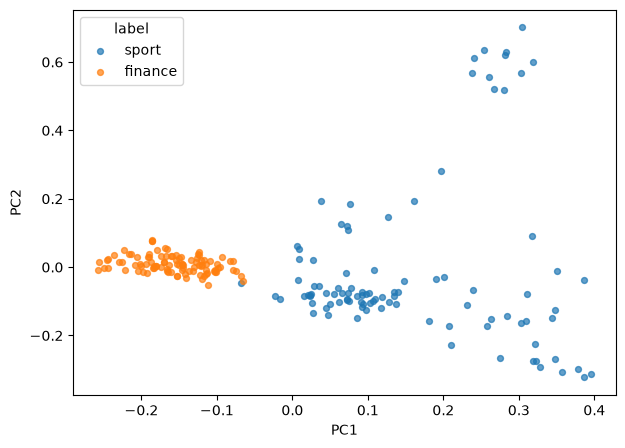

In [33]:
fig, ax = plt.subplots(figsize=(7, 5))
for label, color in [("sport", "#1f77b4"), ("finance", "#d62728")]:
    mask = (df["label"] == label).to_numpy()
    ax.scatter(Z[mask, 0], Z[mask, 1], s=18, alpha=0.7, label=label)
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.legend(title="label")
plt.show()

## Kesimpulan

Korpus siap dipakai pemodelan. Ringkasan angka proses:

In [34]:
pd.DataFrame({
    "metrik": ["dokumen awal", "token bersih", "kata unik", "fitur TF-IDF",
               "varians dua komponen PCA", "artefak yang disisihkan"],
    "nilai": [len(df), sum(final_counts.values()), len(final_counts),
              X.shape[1], f"{evr.sum():.1%}",
              f"URL {n_url}, mata uang {n_curr}, komposit {n_alnum}, "
              f"romawi {n_roman}"],
})

,metrik,nilai
0,dokumen awal,200
1,token bersih,70645
2,kata unik,7399
3,fitur TF-IDF,7399
4,varians dua komponen PCA,6.7%
5,artefak yang disisihkan,"URL 5, mata uang 285, komposit 4073, romawi 126"
